In [42]:
import pandas as pd
import warnings

# 忽略所有警告訊息
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

# 使用剛剛健檢抓到的精確相對路徑
file_path = '../../data/raw/YRBS_2007 2.csv'
df = pd.read_csv(file_path)

# 鎖定資料集裡真正的英文欄位名稱
target_cols = ['SeatBeltUse', 'BicyleHelmetUse', 'CurrentAlcoholUse']

print(f"📊 資料讀取成功！專案總欄位數：{df.shape[1]}")
print("-" * 30)
print("【安全心理學核心欄位資料型態】")
print(df[target_cols].dtypes)

📊 資料讀取成功！專案總欄位數：103
------------------------------
【安全心理學核心欄位資料型態】
SeatBeltUse          float64
BicyleHelmetUse      float64
CurrentAlcoholUse    float64
dtype: object


In [44]:
# 1. 計算核心變數的缺失值與比例
core_missing = df[target_cols].isnull().sum()
core_missing_pct = (df[target_cols].isnull().sum() / len(df)) * 100

print("【核心變數缺失值報告】")
print(pd.DataFrame({'缺失筆數': core_missing, '缺失比例 (%)': core_missing_pct}))

# 2. 剔除核心變數有缺失的資料，建立分析副樣本
analysis_df = df[target_cols].dropna().copy()

# 3. 強制轉成數值型態
for col in target_cols:
    analysis_df[col] = pd.to_numeric(analysis_df[col], errors='coerce')
analysis_df = analysis_df.dropna()

# 4. 資料重新編碼 (Recoding)：安全帶使用狀況分組 (ANOVA用)
# 根據 YRBS 標準：1,2 代表很少/從不繫，3 代表有時，4,5 代表經常/總是
def label_seatbelt(value):
    if value <= 2: return 'High Risk (Rarely/Never)'
    elif value == 3: return 'Medium Risk (Sometimes)'
    else: return 'Low Risk (Always/Most times)'

analysis_df['Seatbelt_Group'] = analysis_df['SeatBeltUse'].apply(label_seatbelt)

print("-" * 30)
print(f"✅ 資料清理與重新編碼完成！用於統計分析的真實樣本數：{len(analysis_df)} 筆")

【核心變數缺失值報告】
                   缺失筆數  缺失比例 (%)
SeatBeltUse         149  1.061178
BicyleHelmetUse     636  4.529592
CurrentAlcoholUse  1372  9.771384
------------------------------
✅ 資料清理與重新編碼完成！用於統計分析的真實樣本數：12224 筆


In [48]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

print("=== 1. ANOVA 描述性統計 (各安全帶組別的平均飲酒表現) ===")
group_stats = analysis_df.groupby('Seatbelt_Group')['CurrentAlcoholUse'].agg(['count', 'mean', 'std'])
print(group_stats)

print("\n=== 2. 執行單因子方差分析 (One-Way ANOVA) ===")
# 檢定不同安全帶組別之間，飲酒表現是否有顯著差異
model_anova = ols('CurrentAlcoholUse ~ C(Seatbelt_Group)', data=analysis_df).fit()
anova_table = sm.stats.anova_lm(model_anova, typ=2)
print(anova_table)

print("\n=== 3. 執行多元線性回歸 (Multiple Linear Regression) ===")
# 用安全帶分數與安全帽分數，預測青少年的飲酒行為
X = analysis_df[['SeatBeltUse', 'BicyleHelmetUse']]
Y = analysis_df['CurrentAlcoholUse']
X = sm.add_constant(X) # 加上常數項

model_reg = sm.OLS(Y, X).fit()
print(model_reg.summary())

=== 1. ANOVA 描述性統計 (各安全帶組別的平均飲酒表現) ===
                              count      mean       std
Seatbelt_Group                                         
High Risk (Rarely/Never)       1189  2.524811  1.721942
Low Risk (Always/Most times)   9260  1.782505  1.182457
Medium Risk (Sometimes)        1775  2.154366  1.398119

=== 2. 執行單因子方差分析 (One-Way ANOVA) ===
                         sum_sq       df           F        PR(>F)
C(Seatbelt_Group)    705.926255      2.0  216.368468  4.547505e-93
Residual           19936.187619  12221.0         NaN           NaN

=== 3. 執行多元線性回歸 (Multiple Linear Regression) ===
                            OLS Regression Results                            
Dep. Variable:      CurrentAlcoholUse   R-squared:                       0.048
Model:                            OLS   Adj. R-squared:                  0.048
Method:                 Least Squares   F-statistic:                     309.3
Date:                Thu, 18 Jun 2026   Prob (F-statistic):          9.43e-1

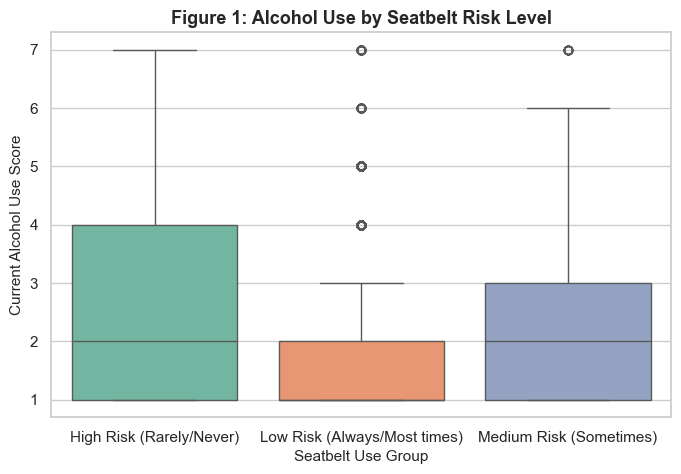

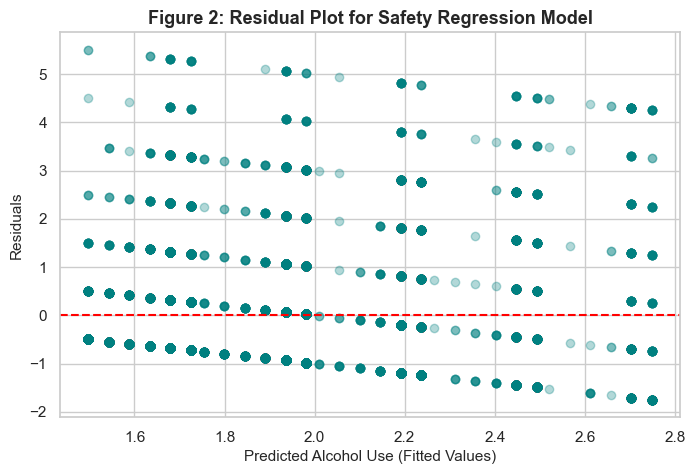

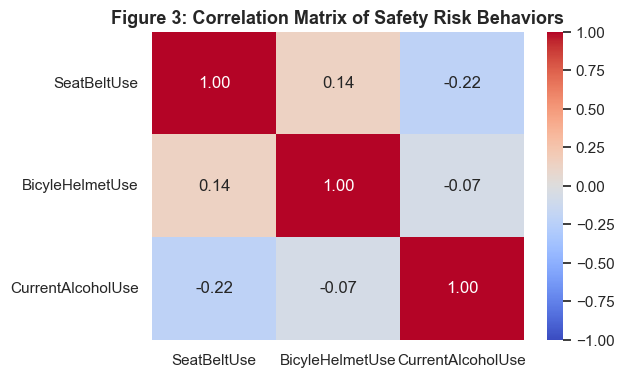

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

# 設定畫風
sns.set_theme(style="whitegrid")

# --- 1. ANOVA 盒鬚圖 ---
plt.figure(figsize=(8, 5))
sns.boxplot(x='Seatbelt_Group', y='CurrentAlcoholUse', data=analysis_df, palette='Set2')
plt.title('Figure 1: Alcohol Use by Seatbelt Risk Level', fontsize=13, fontweight='bold')
plt.xlabel('Seatbelt Use Group', fontsize=11)
plt.ylabel('Current Alcohol Use Score', fontsize=11)
fig1 = plt.gcf()
plt.show()

# --- 2. 回歸分析殘差圖 ---
residuals = model_reg.resid
fitted_values = model_reg.fittedvalues

plt.figure(figsize=(8, 5))
plt.scatter(fitted_values, residuals, alpha=0.3, color='teal')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Figure 2: Residual Plot for Safety Regression Model', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Alcohol Use (Fitted Values)', fontsize=11)
plt.ylabel('Residuals', fontsize=11)
fig2 = plt.gcf()
plt.show()

# --- 3. 相關性熱度圖 ---
plt.figure(figsize=(6, 4))
corr_matrix = analysis_df[target_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Figure 3: Correlation Matrix of Safety Risk Behaviors', fontsize=13, fontweight='bold')
fig3 = plt.gcf()
plt.show()

In [52]:
import os

# 自動根據你專案的結構計算出 outputs 的路徑
save_path = '../../outputs/figures/'
os.makedirs(save_path, exist_ok=True)

# 執行儲存
fig1.savefig(os.path.join(save_path, '02_anova_seatbelt_box.png'), dpi=300, bbox_inches='tight')
fig2.savefig(os.path.join(save_path, '02_regression_residual.png'), dpi=300, bbox_inches='tight')
fig3.savefig(os.path.join(save_path, '02_safety_correlation_heatmap.png'), dpi=300, bbox_inches='tight')

print(f"✅ 成功！3 張統計圖表已成功自動存入：{save_path}")

✅ 成功！3 張統計圖表已成功自動存入：../../outputs/figures/


In [54]:
# 自動定位並存檔至 processed 資料夾
output_path = '../../data/processed/yrbs_safety_psychology_processed.csv'
os.makedirs('../../data/processed/', exist_ok=True)

analysis_df.to_csv(output_path, index=False, encoding='utf-8-sig')

print(f"✅ 專題資料清理完成！已儲存至: {output_path}")
print("🎉 太棒了！你的 Jupyter 全套程式碼和檔案已經全部完美串接成功！")

✅ 專題資料清理完成！已儲存至: ../../data/processed/yrbs_safety_psychology_processed.csv
🎉 太棒了！你的 Jupyter 全套程式碼和檔案已經全部完美串接成功！
